In [30]:
import pandas as pd
import sqlite3
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/processed/hr_cleaned.csv', encoding='utf-8-sig')
conn = sqlite3.connect('../sql/hr_analysis.db')

In [31]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

#### 야근 여부별 직무 만족도 분포

C:\Users\color\AppData\Local\Temp\ipykernel_23160\4227535034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='OverTime', y='JobSatisfaction', palette=['#1f77b4', '#ff7f0e'], ax=ax)


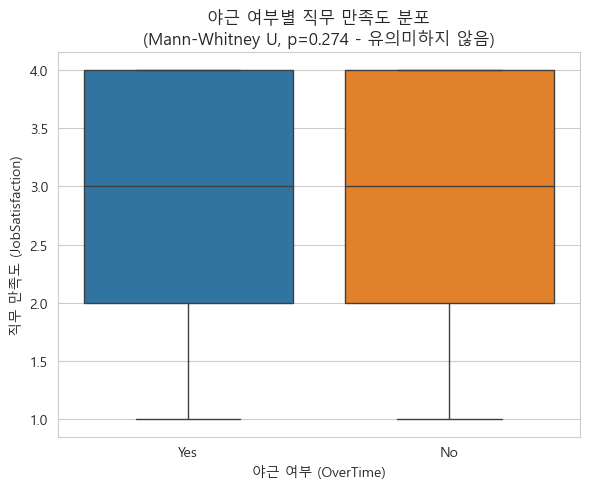

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='OverTime', y='JobSatisfaction', palette=['#1f77b4', '#ff7f0e'], ax=ax)
ax.set_title('야근 여부별 직무 만족도 분포\n(Mann-Whitney U, p=0.274 - 유의미하지 않음)', fontsize=12)
ax.set_xlabel('야근 여부 (OverTime)')
ax.set_ylabel('직무 만족도 (JobSatisfaction)')
plt.tight_layout()
plt.savefig('../outputs/charts/boxplot_overtime_satisfaction.png', dpi=150)
plt.show()

#### 야근 여부별 실제 퇴사율

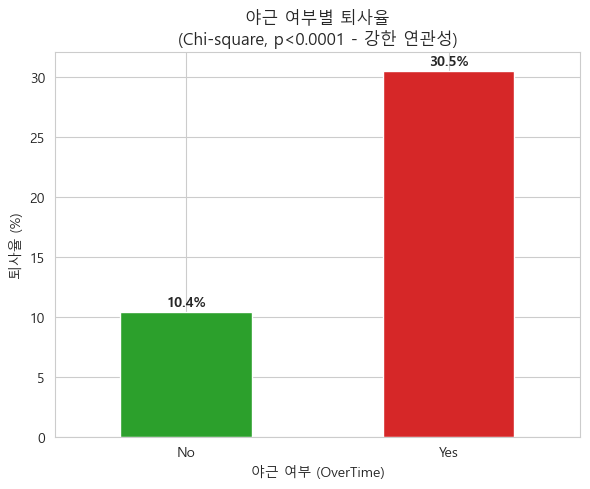

In [33]:
crosstab = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(6, 5))
crosstab['Yes'].plot(kind='bar', color=['#2ca02c', '#d62728'], ax=ax)
ax.set_title('야근 여부별 퇴사율\n(Chi-square, p<0.0001 - 강한 연관성)', fontsize=12)
ax.set_xlabel('야근 여부 (OverTime)')
ax.set_ylabel('퇴사율 (%)')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for i, v in enumerate(crosstab['Yes']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/overtime_attrition_rate.png', dpi=150)
plt.show()

#### 부서별 퇴사율 vs 평균 급여

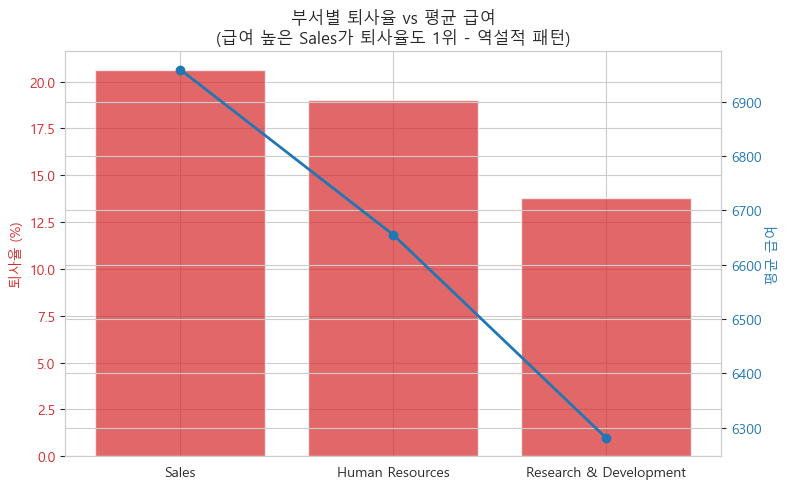

In [34]:
dept_risk = pd.read_sql("""
    SELECT
        Department,
        COUNT(*) AS total_employees,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS attrition_count,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS attrition_rate_pct,
        ROUND(AVG(MonthlyIncome), 0) AS avg_monthly_income
    FROM employees
    GROUP BY Department
    ORDER BY attrition_rate_pct DESC
""", conn)

fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = '#d62728'
ax1.bar(dept_risk['Department'], dept_risk['attrition_rate_pct'], color=color1, alpha=0.7, label='퇴사율(%)')
ax1.set_ylabel('퇴사율 (%)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.plot(dept_risk['Department'], dept_risk['avg_monthly_income'], color=color2, marker='o', linewidth=2, label='평균급여')
ax2.set_ylabel('평균 급여', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('부서별 퇴사율 vs 평균 급여\n(급여 높은 Sales가 퇴사율도 1위 - 역설적 패턴)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/charts/dept_attrition_vs_income.png', dpi=150)
plt.show()

#### 직무별 위험도 순위 

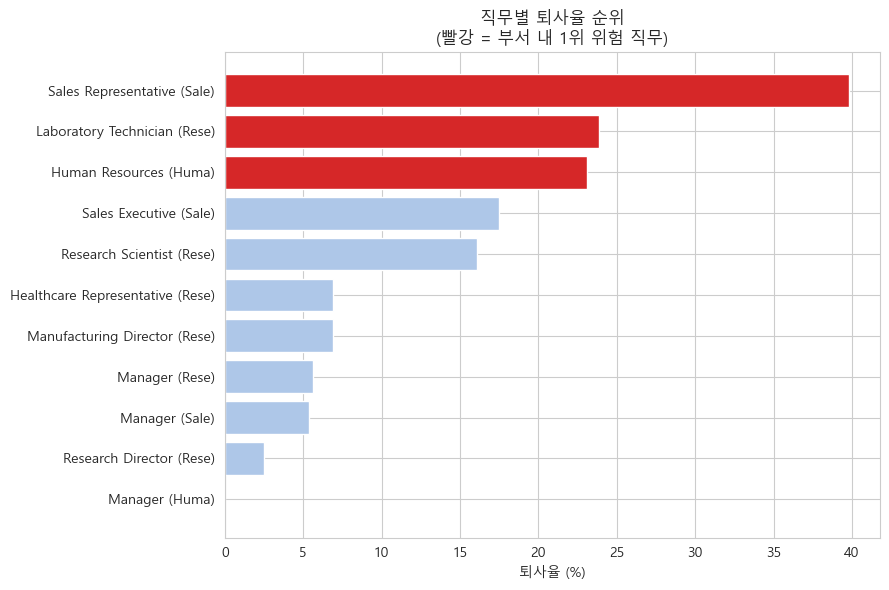

In [35]:
jobrole_risk = pd.read_sql("""
    WITH jobrole_stats AS (
        SELECT
            Department,
            JobRole,
            COUNT(*) AS total_employees,
            SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS attrition_count,
            ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS attrition_rate_pct,
            ROUND(AVG(MonthlyIncome), 0) AS avg_monthly_income
        FROM employees
        GROUP BY Department, JobRole
    )
    SELECT *,
        RANK() OVER (PARTITION BY Department ORDER BY attrition_rate_pct DESC) AS risk_rank_in_dept
    FROM jobrole_stats
    ORDER BY attrition_rate_pct DESC
""", conn)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d62728' if rank == 1 else '#aec7e8' for rank in jobrole_risk['risk_rank_in_dept']]
bars = ax.barh(jobrole_risk['JobRole'] + ' (' + jobrole_risk['Department'].str[:4] + ')',
                jobrole_risk['attrition_rate_pct'], color=colors)
ax.set_xlabel('퇴사율 (%)')
ax.set_title('직무별 퇴사율 순위\n(빨강 = 부서 내 1위 위험 직무)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/charts/jobrole_risk_ranking.png', dpi=150)
plt.show()

In [36]:
conn.close()